<a href="https://colab.research.google.com/github/SinghRaghvendra/DSPortfolio/blob/main/Detecting_Spam_Emails_Using_Tensorflow_in_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Import neccessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import string
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
nltk.download('stopwords')

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
#load the data set
data = pd.read_csv('/content/spam_ham_dataset.csv')
data.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [ ]:
data.shape

(5171, 4)

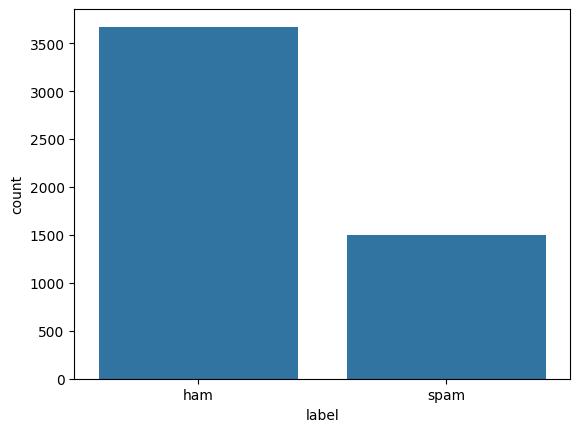

In [ ]:
sns.countplot(x='label', data=data)
plt.show()

Balance the Dataset
We can clearly see that number of samples of Ham is much more than that of Spam which implies that the dataset we are using is imbalanced. To address the imbalance we’ll downsample the majority class (Ham) to match the minority class (Spam).

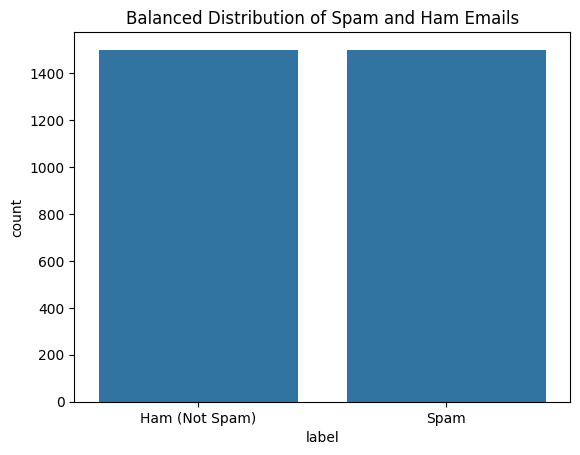

In [ ]:
#Balance the dataset

ham_msg = data[data['label'] == 'ham']
spam_msg = data[data['label'] == 'spam']

# Downsample Ham emails to match the number of Spam emails
ham_msg_balanced = ham_msg.sample(n=len(spam_msg), random_state=42)

# Combine balanced data
balanced_data = pd.concat([ham_msg_balanced, spam_msg]).reset_index(drop=True)

# Visualize the balanced dataset
sns.countplot(x='label', data=balanced_data)
plt.title("Balanced Distribution of Spam and Ham Emails")
plt.xticks(ticks=[0, 1], labels=['Ham (Not Spam)', 'Spam'])
plt.show()

Clean the Text
Textual data often requires preprocessing before feeding it into a machine learning model. Common steps include removing stopwords, punctuations, and performing stemming/lemmatization.

We’ll perform the following steps:

Stopwords Removal
Punctuations Removal
Stemming or Lemmatization

https://www.geeksforgeeks.org/machine-learning/introduction-to-stemming/

https://www.geeksforgeeks.org/python/python-lemmatization-with-nltk/

In [ ]:
balanced_data['text'] = balanced_data['text'].str.replace('Subject', '')
balanced_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,: conoco - big cowboy\r\ndarren :\r\ni ' m not...,0
1,2982,ham,: feb 01 prod : sale to teco gas processing\r\...,0
2,2711,ham,": california energy crisis\r\ncalifornia  , s...",0
3,3116,ham,: re : nom / actual volume for april 23 rd\r\n...,0
4,1314,ham,: eastrans nomination changes effective 8 / 2 ...,0


In [ ]:
punctuations_list = string.punctuation
def remove_punctuations(text):
    temp = str.maketrans('', '', punctuations_list)
    return text.translate(temp)

balanced_data['text']= balanced_data['text'].apply(lambda x: remove_punctuations(x))
balanced_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,conoco big cowboy\r\ndarren \r\ni m not sur...,0
1,2982,ham,feb 01 prod sale to teco gas processing\r\ns...,0
2,2711,ham,california energy crisis\r\ncalifornia  s p...,0
3,3116,ham,re nom actual volume for april 23 rd\r\nwe ...,0
4,1314,ham,eastrans nomination changes effective 8 2 0...,0


In [ ]:
#remove stopwords

def remove_stopwords(text):
    stop_words = stopwords.words('english')

    imp_words = []

    # Storing the important words
    for word in str(text).split():
        word = word.lower()

        if word not in stop_words:
            imp_words.append(word)

    output = " ".join(imp_words)

    return output


balanced_data['text'] = balanced_data['text'].apply(lambda text: remove_stopwords(text))
balanced_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,conoco big cowboy darren sure help know else a...,0
1,2982,ham,feb 01 prod sale teco gas processing sale deal...,0
2,2711,ham,california energy crisis california  power cr...,0
3,3116,ham,nom actual volume april 23 rd agree eileen pon...,0
4,1314,ham,eastrans nomination changes effective 8 2 00 p...,0


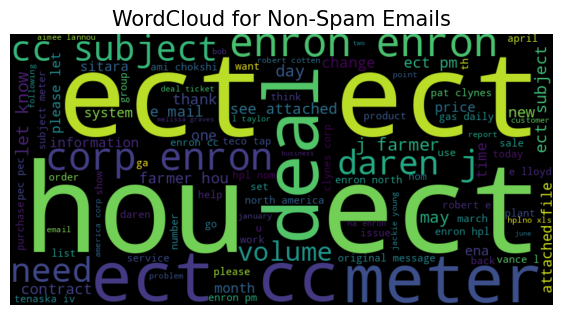

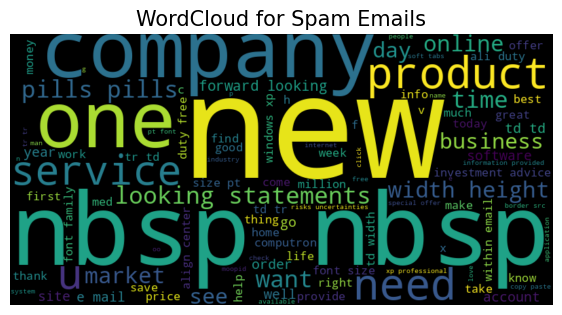

In [ ]:
#text visualization & text cloud

def plot_word_cloud(data, typ):
    email_corpus = " ".join(data['text'])
    wc = WordCloud(background_color='black', max_words=100, width=800, height=400).generate(email_corpus)
    plt.figure(figsize=(7, 7))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f'WordCloud for {typ} Emails', fontsize=15)
    plt.axis('off')
    plt.show()

plot_word_cloud(balanced_data[balanced_data['label'] == 'ham'], typ='Non-Spam')
plot_word_cloud(balanced_data[balanced_data['label'] == 'spam'], typ='Spam')

Tokenization and Padding
Machine learning models work with numbers, so we need to convert the text data into numerical vectors using Tokenization and Padding.

Tokenization: Converts each word into a unique integer.
Padding: Ensures that all text sequences have the same length, making them compatible with the model.

In [ ]:
train_X, test_X, train_Y, test_Y = train_test_split(
    balanced_data['text'], balanced_data['label'], test_size=0.2, random_state=42
)

tokenizer = Tokenizer()
tokenizer.fit_on_texts(train_X)

train_sequences = tokenizer.texts_to_sequences(train_X)
test_sequences = tokenizer.texts_to_sequences(test_X)

max_len = 100  # Maximum sequence length
train_sequences = pad_sequences(train_sequences, maxlen=max_len, padding='post', truncating='post')
test_sequences = pad_sequences(test_sequences, maxlen=max_len, padding='post', truncating='post')

train_Y = (train_Y == 'spam').astype(int)
test_Y = (test_Y == 'spam').astype(int)

Define the Model
We will build a deep learning model using a Sequential architecture. This model will include:

Embedding Layer: Learns vector representations of words.
LSTM Layer: Captures patterns in sequences.
Fully Connected Layer: Extracts relevant features.
Output Layer: Predicts whether an email is spam or not.

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=32, input_length=max_len),
    tf.keras.layers.LSTM(16),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')  # Output layer
])

model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False), # Changed from_logits to False
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Train the Model
We train the model using EarlyStopping and ReduceLROnPlateau callbacks. These callbacks help stop the training early if the model’s performance doesn’t improve and reduce the learning rate to fine-tune the model

In [ ]:
es = EarlyStopping(patience=3, monitor='val_accuracy', restore_best_weights=True)
lr = ReduceLROnPlateau(patience=2, monitor='val_loss', factor=0.5, verbose=0)

history = model.fit(
    train_sequences, train_Y,
    validation_data=(test_sequences, test_Y),
    epochs=20,
    batch_size=32,
    callbacks=[lr, es]
)

Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.6343 - loss: 0.6069 - val_accuracy: 0.9183 - val_loss: 0.2640 - learning_rate: 0.0010
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.9320 - loss: 0.2263 - val_accuracy: 0.9533 - val_loss: 0.2239 - learning_rate: 0.0010
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.9420 - loss: 0.2284 - val_accuracy: 0.9500 - val_loss: 0.1979 - learning_rate: 0.0010
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9570 - loss: 0.1761 - val_accuracy: 0.9567 - val_loss: 0.1763 - learning_rate: 0.0010
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.9629 - loss: 0.1581 - val_accuracy: 0.9533 - val_loss: 0.1834 - learning_rate: 0.0010
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.9762 - loss: 0.1101 - val_accuracy: 0.9550 - val_loss: 0.1809 - learning_rate: 0.0010
Epoch 7/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.9758 - loss: 0.1121 - val_acc

In [ ]:
#Lets evaluate the model on test data to measure its perfromances

test_loss, test_accuracy = model.evaluate(test_sequences, test_Y)
print('Test Loss :',test_loss)
print('Test Accuracy :',test_accuracy)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9750 - loss: 0.0942
Test Loss : 0.09415270388126373
Test Accuracy : 0.9750000238418579


the training accuracy turns out to be 97% which is quite satisfactory.

Having trained our model, we can plot a graph depicting the variance of training and validation accuracies with the no. of epochs.

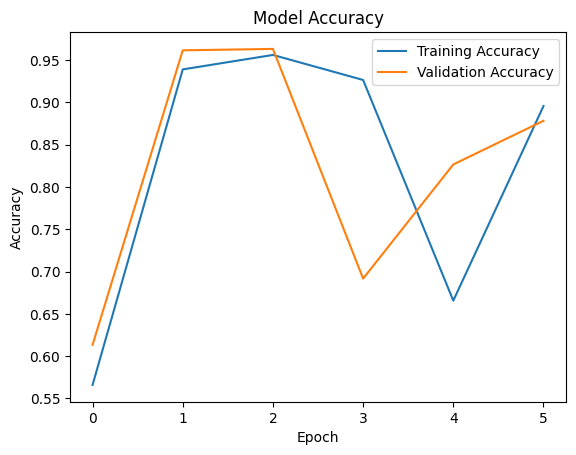

In [ ]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

successfully built a machine learning model that can classify emails as spam or ham. With further optimization, this model can be fine-tuned to improve its performance even more.

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.94      0.96       315
           1       0.94      0.99      0.96       285

    accuracy                           0.96       600
   macro avg       0.96      0.96      0.96       600
weighted avg       0.96      0.96      0.96       600



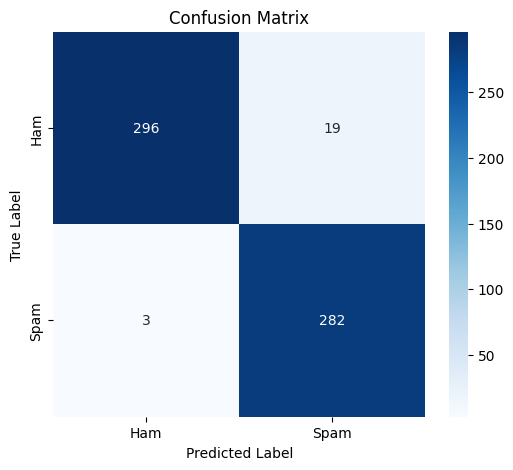

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate predictions on the test set
predictions = model.predict(test_sequences)

# Convert probabilities to binary predictions (0 or 1)
binary_predictions = (predictions > 0.5).astype(int)

# Print classification report
print("Classification Report:")
print(classification_report(test_Y, binary_predictions))

# Plot confusion matrix
cm = confusion_matrix(test_Y, binary_predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

The classification report and confusion matrix have been successfully generated, providing a detailed evaluation of the model's performance. The model achieved an overall accuracy of 96%. Here's a breakdown:

Classification Report:

Precision for Ham (0): 0.99 (Meaning 99% of emails predicted as Ham were actually Ham).
Recall for Ham (0): 0.94 (Meaning 94% of actual Ham emails were correctly identified).
Precision for Spam (1): 0.94 (Meaning 94% of emails predicted as Spam were actually Spam).
Recall for Spam (1): 0.99 (Meaning 99% of actual Spam emails were correctly identified).
The F1-score, which is the harmonic mean of precision and recall, is 0.96 for both classes, indicating a good balance between precision and recall.
Confusion Matrix:

True Ham (Top-left): 296 emails were correctly classified as Ham.
False Spam (Top-right): 19 Ham emails were incorrectly classified as Spam (Type I error).
False Ham (Bottom-left): 3 Spam emails were incorrectly classified as Ham (Type II error).
True Spam (Bottom-right): 282 emails were correctly classified as Spam.
This indicates that the model is performing very well, with a high capability to identify both ham and spam emails.

In [ ]:
# Function to preprocess new email text
def preprocess_new_text(text):
    text = text.replace('Subject', '')
    text = remove_punctuations(text)
    text = remove_stopwords(text)
    return text

# Example test cases
new_emails = [
    "Subject: Free money now!!! Click here to claim your prize!",
    "Subject: Meeting reminder for tomorrow at 10 AM",
    "Subject: Urgent: Your account has been compromised, verify now!",
    "Subject: Project update for Q3 review"
]

# Preprocess the new emails
preprocessed_emails = [preprocess_new_text(email) for email in new_emails]

# Tokenize and pad the preprocessed emails
new_sequences = tokenizer.texts_to_sequences(preprocessed_emails)
new_padded_sequences = pad_sequences(new_sequences, maxlen=max_len, padding='post', truncating='post')

# Make predictions
predictions = model.predict(new_padded_sequences)

# Interpret the predictions
for i, prediction in enumerate(predictions):
    label = 'Spam' if prediction[0] > 0.5 else 'Ham'
    print(f"Email: '{new_emails[i]}'\nPredicted as: {label} (Probability: {prediction[0]:.4f})\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
Email: 'Subject: Free money now!!! Click here to claim your prize!'
Predicted as: Spam (Probability: 0.9621)

Email: 'Subject: Meeting reminder for tomorrow at 10 AM'
Predicted as: Spam (Probability: 0.9621)

Email: 'Subject: Urgent: Your account has been compromised, verify now!'
Predicted as: Spam (Probability: 0.9621)

Email: 'Subject: Project update for Q3 review'
Predicted as: Spam (Probability: 0.9621)



It seems that all the test emails are being predicted as 'Spam' with the same probability, which is unexpected and indicates an issue with the model's setup. The problem lies in how the model was compiled: you've used a sigmoid activation in the final layer, which outputs probabilities, but also set from_logits=True in the BinaryCrossentropy loss function. This effectively applies the sigmoid twice, causing numerical instability and leading to these incorrect predictions. I will fix this by changing from_logits to False in the model compilation. After this, we'll need to re-run the model training and then re-evaluate the test cases.

Excellent! The model has been re-compiled with the corrected loss function. The next step is to retrain the model with these changes. After retraining, we'll evaluate its performance on the test data and then re-run the test cases to confirm the predictions are now accurate.